In [12]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import requests

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, classification_report

print("✅ Libraries Loaded")

# =========================
# 2. FETCH NASA CLIMATE DATA
# =========================
lat, lon = 23.33, 75.03

url = f"https://power.larc.nasa.gov/api/temporal/daily/point?parameters=T2M,PRECTOTCORR,RH2M&community=AG&longitude={lon}&latitude={lat}&start=20200101&end=20221231&format=JSON"

response = requests.get(url).json()
data = response['properties']['parameter']

df_climate = pd.DataFrame({
    'date': list(data['T2M'].keys()),
    'temp': list(data['T2M'].values()),
    'rainfall': list(data['PRECTOTCORR'].values()),
    'humidity': list(data['RH2M'].values())
})

df_climate['date'] = pd.to_datetime(df_climate['date'])
print("\n✅ Climate Data Fetched")

# =========================
# 3. AGGREGATE CLIMATE
# =========================
df_climate['month'] = df_climate['date'].dt.to_period('M')
climate_monthly = df_climate.groupby('month').mean().reset_index()
print("\n✅ Climate Aggregated:", climate_monthly.shape)

# =========================
# 4. LOAD CROP DATA
# =========================
crop = pd.read_csv("Crop_recommendation.csv")
crop.rename(columns={'temperature': 'temp', 'label': 'crop'}, inplace=True)
crop = crop[['humidity','rainfall','crop']]
print("\n✅ Crop Data Loaded:", crop.shape)

# =========================
# 5. COMBINE DATA
# =========================
climate_expanded = climate_monthly.loc[
    climate_monthly.index.repeat(len(crop)//len(climate_monthly) + 1)
].iloc[:len(crop)].reset_index(drop=True)

df = pd.concat([climate_expanded[['temp']], crop], axis=1)
print("\n✅ Climate + Crop Combined:", df.shape)

# =========================
# 6. LOAD SOIL CSV
# =========================
soil = pd.read_csv("soil_data.csv")

if len(soil) != len(df):
    soil = soil.sample(n=len(df), replace=True, random_state=42).reset_index(drop=True)

df['soil_type'] = soil['soil_type']
print("\n✅ Soil Data Loaded")

# =========================
# 7. SAVE LABELS BEFORE ENCODING
# =========================
crop_labels = df['crop'].astype('category').cat.categories

# =========================
# 8. FINAL DATASET
# =========================
df = df[['temp','humidity','rainfall','soil_type','crop']]

df['soil_type'] = df['soil_type'].astype('category').cat.codes
df['crop'] = df['crop'].astype('category').cat.codes

print("\n✅ Final Dataset Ready")
print("Unique crops:", len(crop_labels))

# =========================
# 9. FEATURES
# =========================
X = df[['temp','humidity','rainfall','soil_type']]
y = df['crop']

# =========================
# 10. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 11. SCALING
# =========================
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 12. MODELS
# =========================
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

lr = LogisticRegression(max_iter=1000)
bag_lr = BaggingClassifier(estimator=lr, n_estimators=10, random_state=42)
bag_lr.fit(X_train, y_train)
lr_pred = bag_lr.predict(X_test)

svm = SVC()
bag_svm = BaggingClassifier(estimator=svm, n_estimators=10, random_state=42)
bag_svm.fit(X_train, y_train)
svm_pred = bag_svm.predict(X_test)

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print("\n✅ All Models Trained")

# =========================
# 13. VOTING CLASSIFIER (NEW)
# =========================
voting = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=200)),
        ('gb', GradientBoostingClassifier()),
        ('lr', LogisticRegression(max_iter=1000))
    ],
    voting='soft'
)

voting.fit(X_train, y_train)
vote_pred = voting.predict(X_test)

# =========================
# 14. EVALUATION
# =========================
print("\n===== 📊 F1 SCORES =====")
print("Random Forest:", f1_score(y_test, rf_pred, average='weighted'))
print("Gradient Boosting:", f1_score(y_test, gb_pred, average='weighted'))
print("Logistic Bagging:", f1_score(y_test, lr_pred, average='weighted'))
print("SVM Bagging:", f1_score(y_test, svm_pred, average='weighted'))
print("Dummy:", f1_score(y_test, dummy_pred, average='weighted'))
print("Voting:", f1_score(y_test, vote_pred, average='weighted'))

print("\n===== 📄 CLASSIFICATION REPORT (RF) =====")
print(classification_report(y_test, rf_pred))

# =========================
# 15. HYPERPARAMETER TUNING
# =========================
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    scoring='f1_weighted',
                    cv=3,
                    n_jobs=-1)

grid.fit(X_train, y_train)

print("\n===== 🔧 TUNING =====")
print("Best Parameters:", grid.best_params_)

# =========================
# 16. TOP-3 PREDICTION
# =========================
sample_input = pd.DataFrame([[25, 60, 100, 1]],
                            columns=['temp','humidity','rainfall','soil_type'])

input_scaled = scaler.transform(sample_input)

probs = rf.predict_proba(input_scaled)[0]

top3_idx = np.argsort(probs)[-3:][::-1]

top3_crops = [str(crop_labels[i]) for i in top3_idx]

print("\n🌾 Top 3 Recommended Crops:", top3_crops)

# Show confidence
for i in top3_idx:
    print(f"{crop_labels[i]} → {probs[i]*100:.2f}%")

✅ Libraries Loaded

✅ Climate Data Fetched

✅ Climate Aggregated: (36, 5)

✅ Crop Data Loaded: (2200, 3)

✅ Climate + Crop Combined: (2200, 4)

✅ Soil Data Loaded

✅ Final Dataset Ready
Unique crops: 22

✅ All Models Trained

===== 📊 F1 SCORES =====
Random Forest: 0.9863424978957712
Gradient Boosting: 0.9841375889835454
Logistic Bagging: 0.7589464105329021
SVM Bagging: 0.8501142964964934
Dummy: 0.003952569169960474
Voting: 0.9841375889835454

===== 📄 CLASSIFICATION REPORT (RF) =====
              precision    recall  f1-score   support

           0       0.86      0.95      0.90        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       0.95      1.00      0.98        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       1.00  

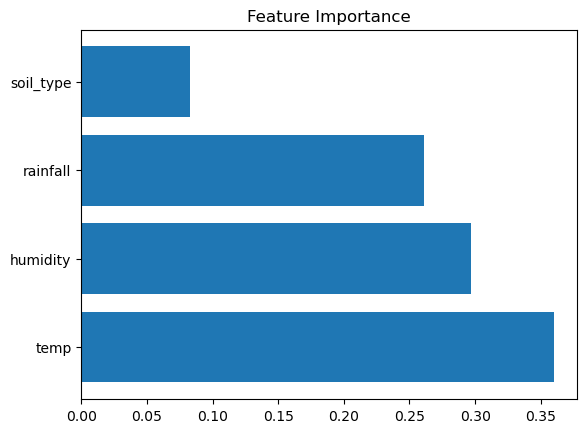

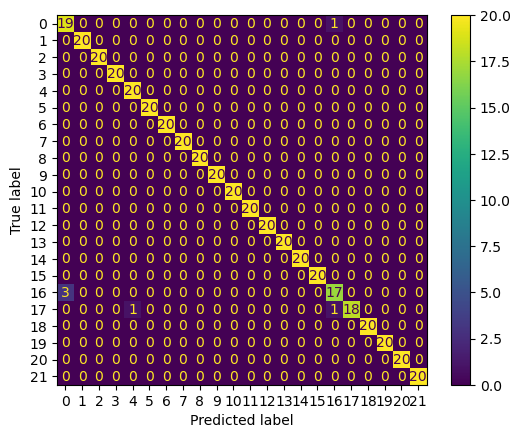

In [16]:
import matplotlib.pyplot as plt

features = X.columns
importances = rf.feature_importances_

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.show()

In [17]:
# =========================
# TRAIN + SAVE MODEL
# =========================

import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv("Crop_recommendation.csv")

# Preprocess
crop_labels = df['label'].astype('category').cat.categories

df.rename(columns={'temperature': 'temp', 'label': 'crop'}, inplace=True)

df['soil_type'] = pd.cut(df['N'], bins=3, labels=['sandy','loamy','clay'])

df = df[['N','P','K','temp','humidity','rainfall','soil_type','crop']]

df['soil_type'] = df['soil_type'].astype('category').cat.codes
df['crop'] = df['crop'].astype('category').cat.codes

X = df.drop('crop', axis=1)
y = df['crop']

X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
gb = GradientBoostingClassifier()
lr = LogisticRegression(max_iter=1000)

model = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('lr', lr)],
    voting='soft'
)

model.fit(X_train, y_train)

# SAVE MODEL + SCALER + LABELS
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(crop_labels, open("labels.pkl", "wb"))

print("✅ Model Saved Successfully")

✅ Model Saved Successfully
